# Lecture 22 - Recurrent Neural Networks

Recurrent neural networks are simply networks that can have connections going backward in the network, unlike the nets we have seen so far.

Here, we introduce an idea of timesteps where we input a datapoint to the net at each timestep. As a datapoint passes through an RNN, it will proceed to the output layer but the information being sent through the reverse connections will be fed into the net while the next datapoint is passed through the RNN.

## Why Are Backward Connections Useful?

The way RNNs operate means the current datapoint will receive information derived from the previous datapoint since weights will persist and feed information into the net as a new datapoint goes through the net.

The prior information continues to influence how the net operates because, at a third timestep, the information will continue going through the loops in the network architecture, the same at the fourth step, and so on. Therefore, a fundamental difference between RNNs and the nets we have seen in the past is this persistent "memory" of previous datapoints, which allows us to use context of the previous datapoints to make inferences about each datapoint.

### Examples

If we have a paragraph of text, we could feed it into the net word-by-word and try to classify the whole sequence. It gives us the power of using the *context* built by the other words in the paragraph. Any use of language, such as recognizing spoken words, handwritten text, or sign language, can benefit from this.

In addition, in handwriting recognition where we have a whole word of text, certainly knowing some letters in the word can help you figure out an unknown letter in the center. For example, if we have a K, it is very very unlikely the next letter will be a Q in English. For another example, here's a word I wrote:

![img](../images/feature.png)

Obviously, being an intelligent human, you know the third letter is an 'a' and not a 'u' because "feuture" isn't a word and your professor has passable spelling skills. However, looking at that letter in isolation makes its identity totally ambiguous. Letter/digit recognition is the kind of task we have assigned to neural nets before, but RNNs have a more unique ability to read letters one-by-one, and use the past letters to influence later classifications.

The commonality in all of these examples is that they all involve making inferences about *sequences* of inputs (letters, words, signs), rather than just individual inputs.

Note that we are talking only of new datapoints being influenced by prior datapoints, but we will also learn about bidirectional RNNs, which look both forward and backward in time by distances the net will learn.

Of course, CNNs also use local structure within datapoints to make inferences about the whole datapoint too, but we have to specify what size filters and how many filters to use for this. With RNNs, the net will automatically learn to use as much of the past information as it needs to use for a given point.

## Training RNNs

The most common approach to training RNNs is essentially the same as any other neural net we have seen: stochastic gradient descent and backpropagation. SGD will operate just the same as the other nets. Recall we have used backpropagation to compute exact gradients needed by SGD by systematic use of the chain rule propagating backwards from the loss function to the weights and biases in the network.

RNNs present a challenge to this idea--what does it mean to propagate backwards in a net that has loops?! There would be infinite paths the method could take since there are loops it could traverse arbitrarily many times.

## Sentiment Analysis

One area of application of RNNs is in sentiment analysis--attempts to identify the feelings associated with written text. Examples:

* Is a review of a product or service or song or movie positive, neutral, or negative?
* Was someone happy or sad in describing their day?
* Are song lyrics sad or happy or excited?

### Movie Reviews

Let's see what we can do with movie reviews for an experiment in sentiment analysis. The data comes from the Internet Movie Database (IMBD), provided by

* Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. (2011). [Learning Word Vectors for Sentiment Analysis](https://ai.stanford.edu/~amaas/papers/wvSent_acl2011.pdf). *The 49th Annual Meeting of the Association for Computational Linguistics (ACL 2011)*.

The dataset contains 50,000 reviews (half in a training set, half in a testing set). Each dataset has reviews from disjoint sets of movies, at most 30 per movie. Each review on IMDB includes a rating from 0 to 10, but the data includes only negative reviews ($\leq 4$ rating) and positive reviews ($\geq 6$ rating) as the labels for the datapoints.

We will use the dataset to try to classify the reviews as positive or negative.

In [1]:
import platform
import torch

# Device selection: CUDA → MPS (Apple Silicon) → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device.type}\n")

if device.type == "cuda":
    num_gpus = torch.cuda.device_count()
    print(f"Found {num_gpus} CUDA device(s):")
    for idx in range(num_gpus):
        print(f"  [{idx}] {torch.cuda.get_device_name(idx)}")
elif device.type == "mps":
    print("Apple Metal (MPS) device available")
else:
    print("Running on CPU")

print("\nPython:", platform.python_version(), "| PyTorch:", torch.__version__)

Using device: cuda

Found 2 CUDA device(s):
  [0] NVIDIA GeForce RTX 3080 Ti
  [1] NVIDIA GeForce RTX 3080 Ti

Python: 3.9.16 | PyTorch: 2.8.0+cu128


In [2]:
import os
import re
import shutil
import tarfile
import urllib.request

from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader

In [3]:
target_dir = Path("../data/imdb")

# If the dataset is missing, download and extract it
if not target_dir.exists():
    target_dir.mkdir(parents=True, exist_ok=True)
    
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    tgz_path = target_dir.parent / "aclImdb_v1.tar.gz"

    print("Downloading IMDB dataset...")
    urllib.request.urlretrieve(url, tgz_path)

    print("Extracting...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=target_dir)   # extracts 'aclImdb'

    # Move contents from imdb/aclImdb/* → imdb/*
    extracted_root = target_dir / "aclImdb"
    for split in ["train", "test"]:
        os.rename(extracted_root / split, target_dir / split)

    # Remove the remaining aclImdb directory completely
    shutil.rmtree(extracted_root)

    print("Done.")
    
else:
    print("IMDB dataset already exists:", target_dir)

IMDB dataset already exists: ../data/imdb


In [4]:
import re
from pathlib import Path
from collections import Counter

# cleaning & tokenization helpers

TOKEN_RE = re.compile(r"\b\w+\b")  # simple word tokens: letters/numbers/underscore

def clean_text(text: str) -> str:
    # mimic regex_replace(text, '<br />', ' ')
    text = text.replace("<br />", " ")
    return text

def tokenize(text: str):
    text = clean_text(text)
    return TOKEN_RE.findall(text.lower())


# load IMDB data from ../data/imdb/train and ../data/imdb/test

def load_imdb_raw_split(root_dir):
    """
    root_dir: '../data/imdb/train' or '../data/imdb/test'
    expects subdirs 'pos' and 'neg' with .txt files
    returns: list of (text, label) where label in {0,1}
    """
    root = Path(root_dir)
    samples = []
    for label_name, label in [("neg", 0), ("pos", 1)]:
        for path in (root / label_name).glob("*.txt"):
            text = path.read_text(encoding="utf-8", errors="ignore")
            samples.append((text, label))
    return samples

train_raw = load_imdb_raw_split("../data/imdb/train")
test_raw  = load_imdb_raw_split("../data/imdb/test")

print("Train size:", len(train_raw))
print("Test size:", len(test_raw))

Train size: 25000
Test size: 25000


In [5]:
max_tokens = 10000           # vocabulary size
sequence_length = 200

def build_vocab(texts, max_tokens, min_freq=1):
    """
    texts: iterable of raw strings
    returns: token_to_id dict, with 0 = PAD, 1 = OOV, 2.. = real words
    """
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))

    # most common words with at least min_freq
    most_common = [w for w, c in counter.most_common() if c >= min_freq]
    most_common = most_common[: max_tokens]

    token_to_id = {"<PAD>": 0, "<OOV>": 1}
    for i, w in enumerate(most_common, start=2):
        token_to_id[w] = i

    return token_to_id

train_texts = [t for (t, y) in train_raw]
token_to_id = build_vocab(train_texts, max_tokens=max_tokens)
vocab_size = len(token_to_id)
print("Vocab size (including PAD & OOV):", vocab_size)

Vocab size (including PAD & OOV): 10002


In [6]:
from torch.utils.data import Dataset, DataLoader, random_split

def encode_text(text: str, token_to_id, seq_len=100):
    tokens = tokenize(text)
    ids = [token_to_id.get(tok, 1) for tok in tokens]  # 1 = OOV
    ids = ids[:seq_len]                                # truncate
    if len(ids) < seq_len:                             # pad
        ids = ids + [0] * (seq_len - len(ids))         # 0 = PAD
    return np.array(ids, dtype=np.int64)

class IMDBDataset(Dataset):
    def __init__(self, samples, token_to_id, seq_len=100):
        self.samples = samples
        self.token_to_id = token_to_id
        self.seq_len = seq_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        text, label = self.samples[idx]
        x = encode_text(text, self.token_to_id, seq_len=self.seq_len)
        y = np.int64(label)
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

batch_size = 32

# train set from train_raw as before
train_dataset = IMDBDataset(train_raw, token_to_id, seq_len=sequence_length)

# eval set from test_raw, then split into val + test
full_eval_dataset = IMDBDataset(test_raw, token_to_id, seq_len=sequence_length)

N = len(full_eval_dataset)
n_val = N // 2
n_test = N - n_val

# deterministic split
g = torch.Generator().manual_seed(0)
val_dataset, test_dataset = random_split(full_eval_dataset, [n_val, n_test], generator=g)

# loaders in the same style as your original code
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

In [7]:
# get batch 0
xb, yb = next(iter(train_loader))

raw_text, raw_label = train_raw[0]
tokens = tokenize(raw_text)
token_ids = xb[0].tolist()
label = yb[0].item()

print("RAW TEXT\n")
print(raw_text, "...")   # print a slice, since reviews are long

print("\nTOKENS\n")
print(tokens, "...")      # preview first 50 tokens

print("\nTOKEN IDs\n")
print(token_ids)

print("\nLABEL\n")
print(label)

RAW TEXT

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [8]:
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report

def binary_accuracy_from_logits(logits, targets):
    """
    Compute accuracy for binary classification when the model outputs raw logits.
    """
    probs = torch.sigmoid(logits)          # Convert logits to probabilities
    preds = (probs >= 0.5).long()          # Threshold at 0.5 to get predicted labels
    return (preds == targets).float().mean().item()  # Average correctness as a Python float


def run_text_experiment(
    model,
    train_loader,
    val_loader,
    *,
    test_loader=None,
    optimizer_name="adamw",
    lr=3e-4,
    weight_decay=1e-2,
    momentum=0.9,
    epochs=100,
    monitor="loss",
    min_delta=0.0,
    patience=10,
    lr_factor=0.5,
    lr_patience=5,
    lr_min=1e-6,
    save_path="best_text_model.pt",
    grad_clip=None,
    seed=0,
):
    """
    Train and evaluate a binary text classifier using preconstructed DataLoaders.

    This function assumes:
    - model(x) returns a 1D tensor of logits with shape (batch_size,)
    - train_loader, val_loader, and optional test_loader yield (inputs, labels) where labels are integer 0/1.

    The function handles:
    - Training and validation loops.
    - Binary cross-entropy with logits loss.
    - AdamW or SGD optimizer.
    - ReduceLROnPlateau learning rate scheduling.
    - Early stopping based on validation loss or accuracy.
    - Best-model checkpoint saving and reloading.
    - Optional test evaluation with confusion matrix and classification report.
    - Loss and accuracy plots over epochs.

    Args:
        model (nn.Module): PyTorch model that maps input batches to logits of shape (B,).
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        test_loader (DataLoader, optional): DataLoader for test data. If None, no final test evaluation is done.
        optimizer_name (str): Name of optimizer to use, "adamw" or "sgd".
        lr (float): Initial learning rate.
        weight_decay (float): Weight decay (L2 regularization) parameter.
        momentum (float): Momentum for SGD (ignored if using AdamW).
        epochs (int): Maximum number of training epochs.
        monitor (str): Metric to monitor for early stopping: "loss" or "acc".
        min_delta (float): Minimum required improvement to count as better.
        patience (int): Number of epochs to wait without improvement before early stopping.
        lr_factor (float): Factor by which to multiply the learning rate when plateauing.
        lr_patience (int): Epochs without improvement before LR is reduced.
        lr_min (float): Lower bound on learning rate.
        save_path (str): Path to save the best model checkpoint.
        grad_clip (float or None): If not None, maximum gradient norm for clipping.
        seed (int): Random seed for reproducibility.

    Returns:
        dict: Dictionary with keys:
            - "history": training and validation loss/accuracy per epoch.
            - "test_acc": test accuracy (or None if no test_loader).
            - "checkpoint": path to saved best-model checkpoint.
            - "device": device string ("cuda", "cpu", or "mps").
            - "total_train_time_sec": total wall-clock training time in seconds.
    """

    # Choose the best available device (CUDA if possible, then MPS, else CPU).
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"[device] Using CUDA: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        device = torch.device("mps")
        print("[device] Using Apple MPS backend")
    else:
        device = torch.device("cpu")
        print("[device] Using CPU")
    print()

    # Set random seeds for reproducibility of weight initialization and shuffling.
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Move model parameters to the chosen device.
    model = model.to(device)

    # Binary cross-entropy with logits combines sigmoid + BCE in a numerically stable way.
    criterion = nn.BCEWithLogitsLoss()

    # Construct the optimizer. Use SGD with momentum or AdamW depending on the flag.
    if optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    # Decide whether to monitor validation loss ("min" mode) or accuracy ("max" mode).
    monitor_metric = monitor.lower()
    scheduler_mode = "min" if monitor_metric == "loss" else "max"

    # ReduceLROnPlateau lowers the LR when the chosen metric stops improving.
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode=scheduler_mode,
        factor=lr_factor,
        patience=lr_patience,
        threshold=min_delta,
        min_lr=lr_min
    )

    # History dictionary stores per-epoch metrics for plotting later.
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # Initialize the best metric depending on whether we minimize loss or maximize accuracy.
    best_metric = float("inf") if monitor_metric == "loss" else 0.0
    # Counter for how many consecutive epochs we have gone without improvement.
    since_improved = 0

    # Track total training time from here.
    train_start_time = time.time()

    # Main training loop over epochs.
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        # Set model to training mode to enable dropout and batch norm updates.
        model.train()
        running_loss = 0.0      # Sum of batch losses (for averaging).
        running_acc = 0.0       # Sum of batch accuracies weighted by batch size.
        total = 0               # Total number of samples seen this epoch.

        # tqdm gives a progress bar over training batches.
        pbar = tqdm(train_loader, desc=f"[epoch {epoch:03d} | train]", leave=False)
        for xb, yb in pbar:
            # Move batch of inputs and labels to the same device as the model.
            xb = xb.to(device)
            yb = yb.to(device)

            # Reset gradients from the previous step.
            optimizer.zero_grad(set_to_none=True)

            # Forward pass: model outputs raw logits of shape (batch_size,).
            logits = model(xb)

            # Compute binary cross-entropy loss given logits and float labels.
            loss = criterion(logits, yb.float())

            # Backpropagate gradients through the model.
            loss.backward()

            # Optionally clip gradients to avoid exploding gradients.
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            # Take one optimizer step to update model parameters.
            optimizer.step()

            # Compute batch size and accuracy for this batch.
            batch_size = xb.size(0)
            acc = binary_accuracy_from_logits(logits.detach(), yb)

            # Accumulate loss and accuracy weighted by batch size.
            running_loss += loss.item() * batch_size
            running_acc += acc * batch_size
            total += batch_size

            # Update the progress bar to display running averages.
            pbar.set_postfix(
                loss=running_loss / total,
                acc=running_acc / total
            )

        # Compute averaged training loss and accuracy for the entire epoch.
        train_loss = running_loss / total
        train_acc = running_acc / total

        # Switch model to evaluation mode for validation (disables dropout, etc.).
        model.eval()
        val_loss_sum = 0.0      # Sum of validation losses.
        val_acc_sum = 0.0       # Sum of validation accuracies.
        val_total = 0           # Total number of validation samples.

        # Progress bar over validation batches.
        pbar_val = tqdm(val_loader, desc=f"[epoch {epoch:03d} | val  ]", leave=False)
        with torch.no_grad():
            # Disable gradient computation for validation for speed and memory.
            for xb, yb in pbar_val:
                xb = xb.to(device)
                yb = yb.to(device)

                # Forward pass in eval mode.
                logits = model(xb)
                loss = criterion(logits, yb.float())

                # Batch accuracy.
                batch_size = xb.size(0)
                acc = binary_accuracy_from_logits(logits, yb)

                # Accumulate weighted loss and accuracy.
                val_loss_sum += loss.item() * batch_size
                val_acc_sum += acc * batch_size
                val_total += batch_size

                # Show running validation loss and accuracy.
                pbar_val.set_postfix(
                    loss=val_loss_sum / val_total,
                    acc=val_acc_sum / val_total
                )

        # Compute averaged validation metrics for this epoch.
        val_loss = val_loss_sum / val_total
        val_acc = val_acc_sum / val_total

        # Store the epoch metrics into the history for plotting later.
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Print a concise epoch summary.
        print(
            f"[epoch {epoch:03d}] "
            f"train loss={train_loss:.4f}, train acc={train_acc:.4f} | "
            f"val loss={val_loss:.4f}, val acc={val_acc:.4f} | "
            f"time={time.time() - epoch_start:.1f}s"
        )

        # Determine the metric value to monitor (loss or accuracy).
        monitored_value = val_loss if monitor_metric == "loss" else val_acc

        # Step the LR scheduler; it will adjust LR when metric plateaus.
        scheduler.step(monitored_value)

        # Check whether this epoch improved upon the previous best metric.
        improved = (
            monitor_metric == "loss" and monitored_value < best_metric - min_delta
        ) or (
            monitor_metric == "acc" and monitored_value > best_metric + min_delta
        )

        if improved:
            # Update the best metric and reset the patience counter.
            best_metric = monitored_value
            since_improved = 0

            # Save the current model state and history as a checkpoint.
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "history": history,
                    "best_metric": best_metric,
                    "monitor": monitor_metric,
                },
                save_path
            )

            tqdm.write(
                f"  [checkpoint saved] new best {monitor_metric}={best_metric:.4f}"
            )
        else:
            # No improvement this epoch; increment the early-stopping counter.
            since_improved += 1
            tqdm.write(
                f"  [no improvement] ({since_improved}/{patience}) on {monitor_metric}"
            )

            # If we have gone patience epochs without improvement, stop training early.
            if since_improved >= patience:
                tqdm.write("  [early stopping triggered]")
                break

    # Compute the total training wall-clock time.
    total_time = time.time() - train_start_time

    # Reload the best-performing model from disk before evaluation/plotting.
    checkpoint_data = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint_data["model_state"])
    history = checkpoint_data["history"]

    print(f"\n[best model reloaded] best {monitor_metric} = {checkpoint_data['best_metric']:.4f}")

    # Set defaults for confusion matrix variables in case test_loader is None
    y_true = None
    y_pred = None

    # Optionally evaluate on a separate test set, if provided.
    test_acc = None
    if test_loader is not None:
        model.eval()
        all_preds = []
        all_trues = []

        with torch.no_grad():
            for xb, yb in tqdm(test_loader, desc="[test]", leave=False):
                xb = xb.to(device)

                # Forward pass on test batch.
                logits = model(xb)
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).long().cpu().numpy()

                # Collect predictions and true labels for the entire test set.
                all_preds.append(preds)
                all_trues.append(yb.numpy())

        # Concatenate across all test batches to compute overall accuracy.
        y_pred = np.concatenate(all_preds).ravel()
        y_true = np.concatenate(all_trues).ravel()
        test_acc = (y_pred == y_true).mean()

        print(f"[test] accuracy = {test_acc:.4f}")
        print(classification_report(y_true, y_pred, target_names=["neg", "pos"]))

    # Prepare an epoch index for plotting training curves.
    epochs_range = range(1, len(history["train_loss"]) + 1)

    # Create a figure with a shared x-axis and two y-axes (loss and accuracy).
    fig, ax1 = plt.subplots()
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="tab:blue")

    # Plot training and validation loss on the left y-axis.
    ax1.plot(epochs_range, history["train_loss"], label="Train Loss", color="tab:blue")
    ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   color="tab:blue", linestyle="--")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Create a second y-axis for accuracy on the same plot.
    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy", color="tab:orange")

    # Plot training and validation accuracy on the right y-axis.
    ax2.plot(epochs_range, history["train_acc"], label="Train Acc", color="tab:orange")
    ax2.plot(epochs_range, history["val_acc"],   label="Val Acc",   color="tab:orange", linestyle="--")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.title("Training Curves")
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Confusion matrix AFTER plots (only if we have test data)
    # ------------------------------------------------------------
    if y_true is not None and y_pred is not None:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["neg", "pos"],
            yticklabels=["neg", "pos"]
        )
        plt.title("Confusion Matrix (Test Set)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    # Return a summary dictionary with metrics, checkpoint path, device, and timing.
    return {
        "history": history,
        "test_acc": float(test_acc) if test_loader is not None else None,
        "checkpoint": save_path,
        "device": str(device),
        "total_train_time_sec": total_time,
    }

## Text Classification Models Implemented

We provide a collection of lightweight neural architectures for IMDB-style sentiment classification.  
All models take as input a sequence of integer token IDs and output a single logit for binary classification.

### 1. SimpleTextMLP
A fast baseline architecture:
- **Embedding** layer maps token IDs to vectors.  
- **Mean pooling** aggregates token embeddings into a document representation.  
- A small **MLP** (Linear → ReLU → Dropout) predicts sentiment.  
- Equivalent to:  
  \[
  $\text{Embedding} \rightarrow \text{AvgPool} \rightarrow \text{MLP} \rightarrow \text{logit}$
  \]
This model is extremely fast and provides a strong baseline.

### 2. CNNTextClassifier
A 1D CNN model:
- Embedding  
- Multiple **Conv1D** filters with kernel sizes $k \in \{3,4,5\}$
- **Global max-pooling** over time for each filter  
- Concatenation of pooled features → Linear → logit  
- Very fast and competitive, especially for shorter sequences.

### 3. SimpleRNNTextClassifier
A recurrent model using:
- Embedding  
- **Simple RNN** ($\tanh$) nonlinearity)  
- Final hidden state used for prediction  
- Good for teaching bottlenecks and sequential behavior, though less expressive than LSTMs.

### 4. GRUTextClassifier
Similar to the LSTM but using a **GRU** cell:
- Embedding  
- GRU  
- Final hidden state → logit  
- Faster than LSTM with comparable accuracy on IMDB.

### 5. LSTMTextClassifier
A standard sequence model for sentiment analysis:
- Embedding  
- **Unidirectional LSTM**  
- Final hidden state becomes the document representation  
- More stable and expressive than a simple RNN.

### 6. BiLSTMTextClassifier
A stronger variant:
- Embedding  
- **Bidirectional LSTM**  
- Concatenated forward and backward final hidden states:  
  \[
  $h = [h_{\text{forward}} ; h_{\text{backward}}]$
  \]
- Typically the strongest RNN-based model in this zoo.

### Summary Table

| Model | Key Idea | Strengths |
|------|----------|-----------|
| **SimpleTextMLP** | Mean-pooled embeddings | Very fast baseline |
| **CNN** | N-gram convolution + max-pool | Fast and competitive |
| **SimpleRNN** | Tanh RNN | Simple, interpretable |
| **GRU** | Gated recurrence | Efficient LSTM alternative |
| **LSTM** | Memory-based recurrence | Stable sequential modeling |
| **BiLSTM** | Forward + backward context | Strongest performance among RNNs |

All models are fully compatible with the `run_text_experiment(...)` training pipeline and can be swapped with a single line of code.

In [9]:
class SimpleTextMLP(nn.Module):
    """
    Simple baseline model:
      Embedding -> mean pooling over time -> MLP -> single logit.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=64,
        pad_idx=0,
        dropout=0.2,
    ):
        """
        Args:
            vocab_size (int): Size of the vocabulary (including PAD and OOV).
            embed_dim (int): Dimension of word embeddings.
            hidden_dim (int): Hidden size of the MLP layer.
            pad_idx (int): Index used for padding tokens (so embedding is masked via padding_idx).
            dropout (float): Dropout applied before the final layer.
        """
        super().__init__()

        # Embedding layer maps token IDs to dense vectors.
        # padding_idx tells PyTorch to keep the PAD embedding at zeros and ignore it in gradients.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # A simple MLP block after pooling: Linear -> ReLU -> Dropout.
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Final linear layer outputs a single logit per example.
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x: LongTensor of shape (batch_size, seq_len) with token IDs.
        Returns:
            logits: Tensor of shape (batch_size,) with raw logits.
        """
        # Shape: (B, L, E)
        emb = self.embedding(x)

        # Mean pooling over the sequence dimension.
        # This is a simple way to aggregate token embeddings into a sentence representation.
        pooled = emb.mean(dim=1)  # (B, E)

        # MLP block with ReLU and dropout.
        h = self.fc1(pooled)      # (B, hidden_dim)
        h = self.relu(h)
        h = self.dropout(h)

        # Final logit; squeeze to get shape (B,)
        logits = self.out(h).squeeze(1)
        return logits
    


class CNNTextClassifier(nn.Module):
    """
    1D CNN text classifier:
      Embedding -> Conv1D + ReLU + GlobalMaxPool over time -> Linear -> logit.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        num_filters=100,
        kernel_sizes=(3, 4, 5),
        pad_idx=0,
        dropout=0.5,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # We use multiple convolutional filters with different kernel sizes (n-grams).
        # Each Conv1d expects input of shape (B, E, L), so we transpose after embedding.
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k,
            )
            for k in kernel_sizes
        ])

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Each conv produces num_filters features; we concatenate across kernel sizes.
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        # Shape: (B, L, E)
        emb = self.embedding(x)

        # Transpose to (B, E, L) for Conv1d.
        emb = emb.transpose(1, 2)

        # Apply each convolution + ReLU + global max pooling over time.
        conv_feats = []
        for conv in self.convs:
            # conv_out: (B, num_filters, L')
            c = conv(emb)
            c = self.relu(c)
            # Global max pooling over time dimension (L').
            pooled = torch.max(c, dim=2).values  # (B, num_filters)
            conv_feats.append(pooled)

        # Concatenate features from all convolutional branches.
        h = torch.cat(conv_feats, dim=1)       # (B, num_filters * len(kernel_sizes))

        h = self.dropout(h)
        logits = self.fc(h).squeeze(1)         # (B,)
        return logits
    


class SimpleRNNTextClassifier(nn.Module):
    """
    Simple RNN-based text classifier:
      Embedding -> RNN -> use last hidden state -> Linear -> logit.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        pad_idx=0,
        dropout=0.2,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Vanilla RNN, batch_first=True so input is (B, L, E).
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        emb = self.embedding(x)         # (B, L, E)

        # rnn_out: (B, L, H), h_n: (num_layers, B, H)
        rnn_out, h_n = self.rnn(emb)

        # Use the last layer's final hidden state as the sentence representation.
        last_hidden = h_n[-1]           # (B, H)

        h = self.dropout(last_hidden)
        logits = self.fc(h).squeeze(1)  # (B,)
        return logits
    


class GRUTextClassifier(nn.Module):
    """
    GRU-based text classifier:
      Embedding -> GRU -> last hidden state -> Linear -> logit.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        pad_idx=0,
        dropout=0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        emb = self.embedding(x)              # (B, L, E)

        # gru_out: (B, L, H), h_n: (num_layers, B, H)
        gru_out, h_n = self.gru(emb)

        last_hidden = h_n[-1]                # (B, H)

        h = self.dropout(last_hidden)
        logits = self.fc(h).squeeze(1)       # (B,)
        return logits
    


class LSTMTextClassifier(nn.Module):
    """
    LSTM-based text classifier:
      Embedding -> LSTM -> last hidden state -> Linear -> logit.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        pad_idx=0,
        dropout=0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # LSTM with batch_first for (B, L, E) input format.
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        emb = self.embedding(x)              # (B, L, E)

        # lstm_out: (B, L, H), (h_n, c_n): each (num_layers, B, H)
        lstm_out, (h_n, c_n) = self.lstm(emb)

        # Take the last layer's final hidden state as the document representation.
        last_hidden = h_n[-1]                # (B, H)

        h = self.dropout(last_hidden)
        logits = self.fc(h).squeeze(1)       # (B,)
        return logits


class BiLSTMTextClassifier(nn.Module):
    """
    Bidirectional LSTM text classifier:
      Embedding -> BiLSTM -> concat last forward/backward states -> Linear -> logit.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        pad_idx=0,
        dropout=0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Bidirectional LSTM doubles the hidden size in the output (forward + backward).
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        # hidden_dim * 2 due to bidirectionality.
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        emb = self.embedding(x)                      # (B, L, E)

        # lstm_out: (B, L, 2H), h_n: (num_layers*2, B, H)
        lstm_out, (h_n, c_n) = self.lstm(emb)

        # h_n is stacked as [layer1_forward, layer1_backward, layer2_forward, ...]
        # We want the final layer's forward and backward states.
        # Forward: h_n[-2], Backward: h_n[-1]
        forward_last = h_n[-2]                       # (B, H)
        backward_last = h_n[-1]                      # (B, H)

        # Concatenate forward/backward to form a single representation.
        last_hidden = torch.cat([forward_last, backward_last], dim=1)  # (B, 2H)

        h = self.dropout(last_hidden)
        logits = self.fc(h).squeeze(1)               # (B,)
        return logits


Training model: MLP
[device] Using CUDA: NVIDIA GeForce RTX 3080 Ti



[epoch 001 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 001 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 001] train loss=0.6421, train acc=0.6535 | val loss=0.5454, val acc=0.7542 | time=4.8s
  [checkpoint saved] new best loss=0.5454


[epoch 002 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

...

[epoch 017 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 017 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 017] train loss=0.1422, train acc=0.9520 | val loss=0.4145, val acc=0.8460 | time=4.6s
  [no improvement] (10/10) on loss
  [early stopping triggered]

[best model reloaded] best loss = 0.3503


[test]:   0%|          | 0/391 [00:00<?, ?it/s]

[test] accuracy = 0.8550
              precision    recall  f1-score   support

         neg       0.86      0.85      0.85      6254
         pos       0.85      0.86      0.86      6246

    accuracy                           0.85     12500
   macro avg       0.86      0.85      0.85     12500
weighted avg       0.86      0.85      0.85     12500



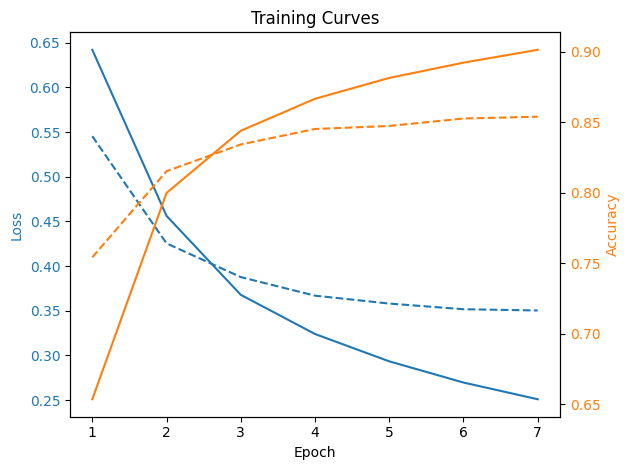

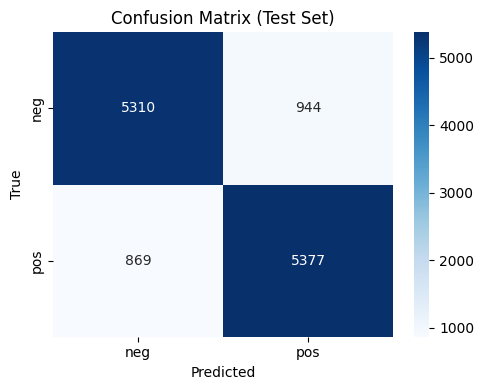


Finished MLP: test_acc = 0.8550


Training model: CNN
[device] Using CUDA: NVIDIA GeForce RTX 3080 Ti



[epoch 001 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 001 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 001] train loss=0.6527, train acc=0.6230 | val loss=0.5082, val acc=0.7692 | time=5.9s
  [checkpoint saved] new best loss=0.5082


[epoch 002 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

...

[epoch 019 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 019 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 019] train loss=0.0803, train acc=0.9717 | val loss=0.3990, val acc=0.8571 | time=5.8s
  [no improvement] (10/10) on loss
  [early stopping triggered]

[best model reloaded] best loss = 0.3220


[test]:   0%|          | 0/391 [00:00<?, ?it/s]

[test] accuracy = 0.8571
              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      6254
         pos       0.86      0.86      0.86      6246

    accuracy                           0.86     12500
   macro avg       0.86      0.86      0.86     12500
weighted avg       0.86      0.86      0.86     12500



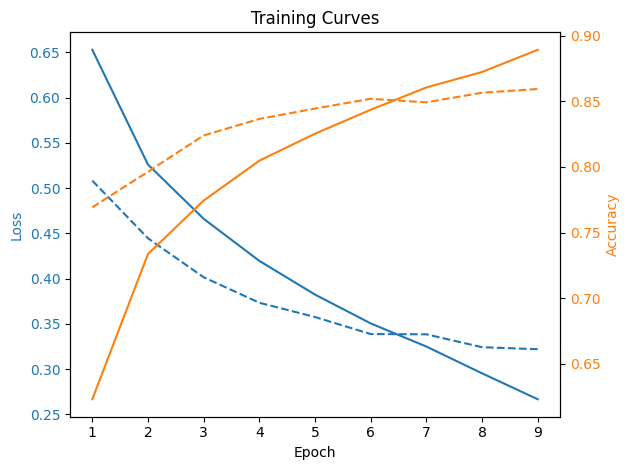

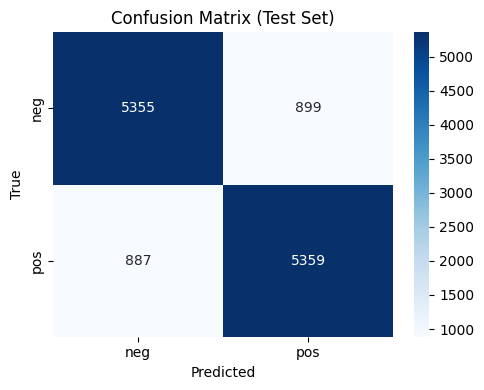


Finished CNN: test_acc = 0.8571


Training model: RNN
[device] Using CUDA: NVIDIA GeForce RTX 3080 Ti



[epoch 001 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 001 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 001] train loss=0.6988, train acc=0.5021 | val loss=0.6980, val acc=0.5074 | time=5.3s
  [checkpoint saved] new best loss=0.6980


[epoch 002 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

...

[epoch 014 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 014 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 014] train loss=0.3747, train acc=0.8217 | val loss=1.1375, val acc=0.6302 | time=5.5s
  [no improvement] (10/10) on loss
  [early stopping triggered]

[best model reloaded] best loss = 0.6822


[test]:   0%|          | 0/391 [00:00<?, ?it/s]

[test] accuracy = 0.6045
              precision    recall  f1-score   support

         neg       0.61      0.59      0.60      6254
         pos       0.60      0.62      0.61      6246

    accuracy                           0.60     12500
   macro avg       0.60      0.60      0.60     12500
weighted avg       0.60      0.60      0.60     12500



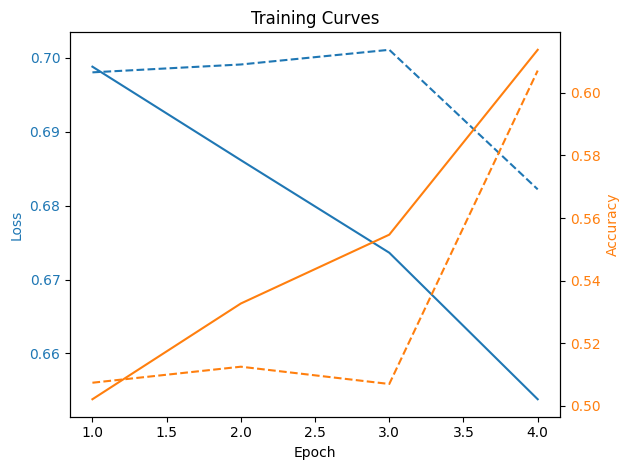

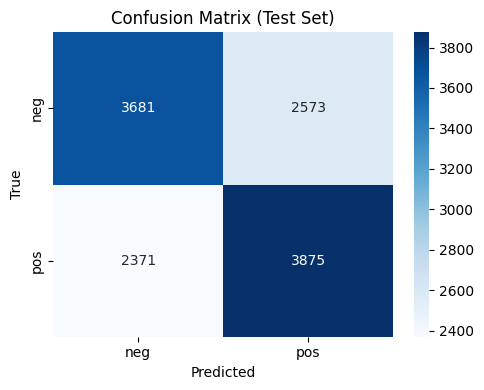


Finished RNN: test_acc = 0.6045


Training model: GRU
[device] Using CUDA: NVIDIA GeForce RTX 3080 Ti



[epoch 001 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 001 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 001] train loss=0.6914, train acc=0.5202 | val loss=0.6725, val acc=0.5832 | time=13.6s
  [checkpoint saved] new best loss=0.6725


[epoch 002 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

...

[epoch 017 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 017 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 017] train loss=0.0055, train acc=0.9988 | val loss=1.0910, val acc=0.8446 | time=14.1s
  [no improvement] (10/10) on loss
  [early stopping triggered]

[best model reloaded] best loss = 0.3656


[test]:   0%|          | 0/391 [00:00<?, ?it/s]

[test] accuracy = 0.8519
              precision    recall  f1-score   support

         neg       0.85      0.86      0.85      6254
         pos       0.85      0.85      0.85      6246

    accuracy                           0.85     12500
   macro avg       0.85      0.85      0.85     12500
weighted avg       0.85      0.85      0.85     12500



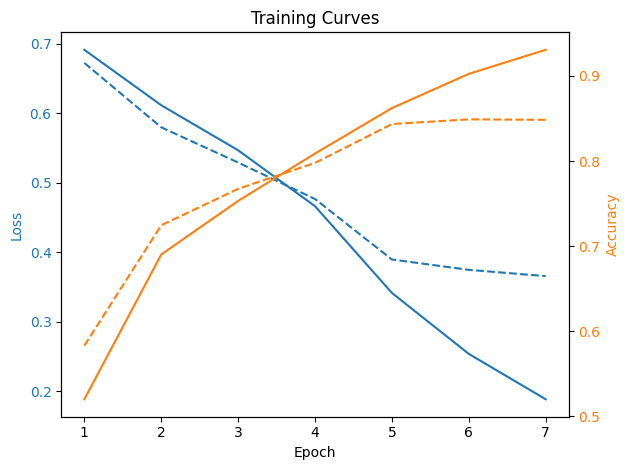

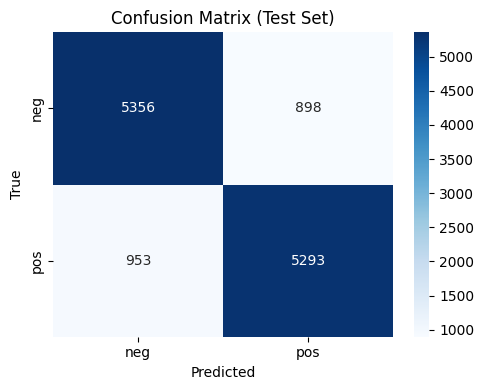


Finished GRU: test_acc = 0.8519


Training model: LSTM
[device] Using CUDA: NVIDIA GeForce RTX 3080 Ti



[epoch 001 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 001 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 001] train loss=0.6823, train acc=0.5511 | val loss=0.6345, val acc=0.6669 | time=13.9s
  [checkpoint saved] new best loss=0.6345


[epoch 002 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

...

[epoch 018 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 018 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 018] train loss=0.0704, train acc=0.9778 | val loss=0.8073, val acc=0.8235 | time=14.3s
  [no improvement] (10/10) on loss
  [early stopping triggered]

[best model reloaded] best loss = 0.5371


[test]:   0%|          | 0/391 [00:00<?, ?it/s]

[test] accuracy = 0.7782
              precision    recall  f1-score   support

         neg       0.77      0.79      0.78      6254
         pos       0.78      0.77      0.78      6246

    accuracy                           0.78     12500
   macro avg       0.78      0.78      0.78     12500
weighted avg       0.78      0.78      0.78     12500



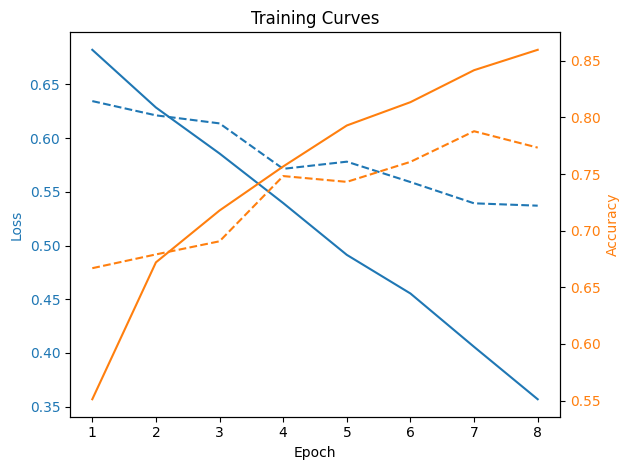

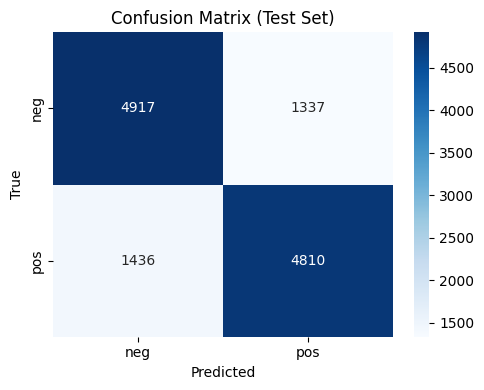


Finished LSTM: test_acc = 0.7782


Training model: BILSTM
[device] Using CUDA: NVIDIA GeForce RTX 3080 Ti



[epoch 001 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 001 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 001] train loss=0.6151, train acc=0.6536 | val loss=0.5409, val acc=0.7386 | time=19.6s
  [checkpoint saved] new best loss=0.5409


[epoch 002 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

...

[epoch 015 | train]:   0%|          | 0/782 [00:00<?, ?it/s]

[epoch 015 | val  ]:   0%|          | 0/391 [00:00<?, ?it/s]

[epoch 015] train loss=0.0052, train acc=0.9989 | val loss=1.0203, val acc=0.8438 | time=20.0s
  [no improvement] (10/10) on loss
  [early stopping triggered]

[best model reloaded] best loss = 0.3940


[test]:   0%|          | 0/391 [00:00<?, ?it/s]

[test] accuracy = 0.8408
              precision    recall  f1-score   support

         neg       0.83      0.86      0.84      6254
         pos       0.85      0.83      0.84      6246

    accuracy                           0.84     12500
   macro avg       0.84      0.84      0.84     12500
weighted avg       0.84      0.84      0.84     12500



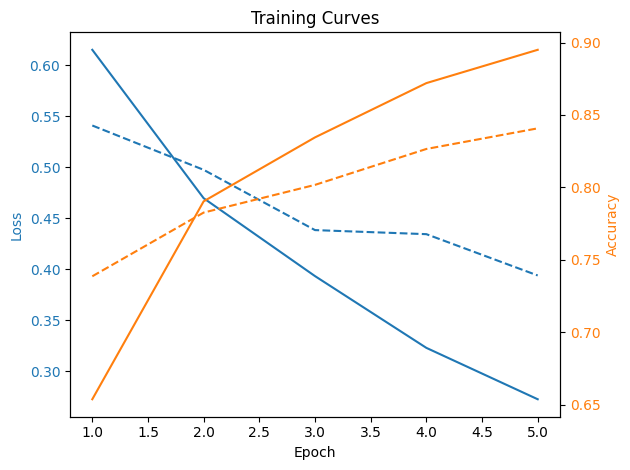

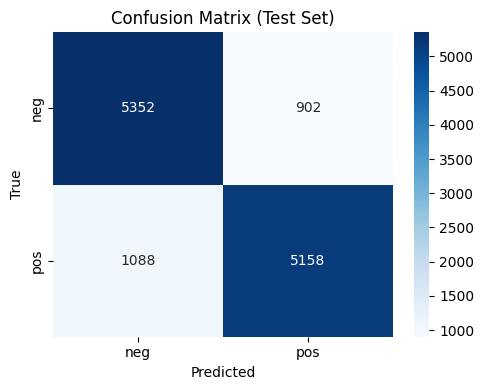


Finished BILSTM: test_acc = 0.8408


Summary of test accuracies:
  mlp    : 0.8550
  cnn    : 0.8571
  rnn    : 0.6045
  gru    : 0.8519
  lstm   : 0.7782
  bilstm : 0.8408


In [11]:
# ============================================================
# Train text models on IMDB in the order:
# MLP → CNN → RNN → GRU → LSTM → BiLSTM
# ============================================================

vocab_size = len(token_to_id)
pad_idx = 0

# Common hyperparameters for ALL models (as requested)
common_train_kwargs = {
    "optimizer_name": "adamw",
    "lr": 3e-4,
    "weight_decay": 1e-2,
    "epochs": 100,
    "monitor": "loss",
    "min_delta": 0.0,
    "patience": 10,
    "lr_factor": 0.5,
    "lr_patience": 5,
    "lr_min": 1e-6,
    "grad_clip": 1.0,
    "seed": 0,
}

# Recurrent model capacity
RNN_EMBED = 256
RNN_HIDDEN = 256

# ------------------------------------------------------------
# Factory to create a model by name
# ------------------------------------------------------------
def make_model(name: str):
    name = name.lower()
    
    if name == "mlp":
        return SimpleTextMLP(
            vocab_size=vocab_size,
            embed_dim=128,
            hidden_dim=64,
            pad_idx=pad_idx,
            dropout=0.2,   # fine
        )

    elif name == "cnn":
        return CNNTextClassifier(
            vocab_size=vocab_size,
            embed_dim=128,
            num_filters=100,
            kernel_sizes=(3, 4, 5),
            pad_idx=pad_idx,
            dropout=0.5,   # standard for CNN
        )

    elif name == "rnn":
        return SimpleRNNTextClassifier(
            vocab_size=vocab_size,
            embed_dim=RNN_EMBED,
            hidden_dim=RNN_HIDDEN,
            num_layers=1,
            pad_idx=pad_idx,
            dropout=0.3,   # good default
        )

    elif name == "gru":
        return GRUTextClassifier(
            vocab_size=vocab_size,
            embed_dim=RNN_EMBED,
            hidden_dim=RNN_HIDDEN,
            num_layers=1,
            pad_idx=pad_idx,
            dropout=0.3,
        )

    elif name == "lstm":
        return LSTMTextClassifier(
            vocab_size=vocab_size,
            embed_dim=RNN_EMBED,
            hidden_dim=RNN_HIDDEN,
            num_layers=1,
            pad_idx=pad_idx,
            dropout=0.3,
        )

    elif name == "bilstm":
        return BiLSTMTextClassifier(
            vocab_size=vocab_size,
            embed_dim=RNN_EMBED,
            hidden_dim=RNN_HIDDEN,
            num_layers=1,
            pad_idx=pad_idx,
            dropout=0.3,
        )

    else:
        raise ValueError(f"Unknown model name: {name}")

# ------------------------------------------------------------
# Train all models in order
# ------------------------------------------------------------

model_order = ["mlp", "cnn", "rnn", "gru", "lstm", "bilstm"]

results = {}

for name in model_order:
    print("\n" + "=" * 70)
    print(f"Training model: {name.upper()}")
    print("=" * 70)
    
    model = make_model(name)
    save_path = f"imdb_{name}_best.pt"

    result = run_text_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        save_path=save_path,
        **common_train_kwargs,
    )

    results[name] = result
    print(f"\nFinished {name.upper()}: test_acc = {result['test_acc']:.4f}\n")


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\nSummary of test accuracies:")
for name in model_order:
    acc = results[name]["test_acc"]
    print(f"  {name:7s}: {acc:.4f}")